In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv(Path("../data/processed/02_nav_history_clean.csv"))
nav["date"] = pd.to_datetime(nav["date"])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-08,515.1639,0.000000
6,100016,2022-01-09,515.1639,0.000000
7,100016,2022-01-10,510.7136,-0.008639
8,100016,2022-01-11,513.5542,0.005562
9,100016,2022-01-12,512.3195,-0.002404


In [4]:
nav["daily_return"].isna().sum()

np.int64(40)

In [5]:
nav["daily_return"].isna().groupby(nav["amfi_code"]).sum().value_counts()

daily_return
1    40
Name: count, dtype: int64

In [6]:
nav["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

In [7]:
nav["date"].min(), nav["date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2026-05-29 00:00:00'))

In [8]:
nav[nav["date"].isin([pd.Timestamp("2025-05-29"), pd.Timestamp("2026-05-29")])].groupby("date")["amfi_code"].nunique()

date
2025-05-29    40
2026-05-29    40
Name: amfi_code, dtype: int64

In [9]:
start_1y = pd.Timestamp("2025-05-29")
end_1y = pd.Timestamp("2026-05-29")
nav_1y = nav[nav["date"].isin([start_1y, end_1y])].copy()
trading_days_1y = (
    nav[(nav["date"] >= start_1y) & (nav["date"] <= end_1y)]
    .groupby("amfi_code")
    .size()
    .sub(1)
    .rename("n_trading_days")
)

In [10]:
cagr_1y = nav_1y.pivot(index="amfi_code", columns="date", values="nav").reset_index()
cagr_1y = cagr_1y.merge(trading_days_1y, on="amfi_code")

In [11]:
cagr_1y["cagr_1yr"] = (
    cagr_1y[end_1y] / cagr_1y[start_1y]
) ** (252 / cagr_1y["n_trading_days"]) - 1

In [12]:
cagr_1y.head()

,amfi_code,2025-05-29 00:00:00,2026-05-29 00:00:00,n_trading_days,cagr_1yr
0,100016,596.8877,583.6113,365,-0.015410
1,100025,30.7452,31.8843,365,0.025435
2,100033,223.1951,342.0072,365,0.342666
3,101206,522.7639,773.2939,365,0.310379
4,101207,71.0180,53.9836,365,-0.172501


In [13]:
nav[nav["date"].isin([pd.Timestamp("2023-05-29"), pd.Timestamp("2026-05-29")])].groupby("date")["amfi_code"].nunique()

date
2023-05-29    40
2026-05-29    40
Name: amfi_code, dtype: int64

In [14]:
start_3y = pd.Timestamp("2023-05-29")
end_3y = pd.Timestamp("2026-05-29")
nav_3y = nav[nav["date"].isin([start_3y, end_3y])].copy()
trading_days_3y = (
    nav[(nav["date"] >= start_3y) & (nav["date"] <= end_3y)]
    .groupby("amfi_code")
    .size()
    .sub(1)
    .rename("n_trading_days")
)

In [15]:
cagr_3y = nav_3y.pivot(index="amfi_code", columns="date", values="nav").reset_index()
cagr_3y = cagr_3y.merge(trading_days_3y, on="amfi_code")

In [16]:
cagr_3y["cagr_3yr"] = (
    cagr_3y[end_3y] / cagr_3y[start_3y]
) ** (252 / cagr_3y["n_trading_days"]) - 1

In [17]:
cagr_3y.head()

,amfi_code,2023-05-29 00:00:00,2026-05-29 00:00:00,n_trading_days,cagr_3yr
0,100016,561.5519,583.6113,1096,0.008899
1,100025,28.4135,31.8843,1096,0.026853
2,100033,147.2155,342.0072,1096,0.213870
3,101206,360.4971,773.2939,1096,0.191812
4,101207,61.3081,53.9836,1096,-0.028830


In [18]:
cagr_table = cagr_1y[["amfi_code", "cagr_1yr"]].merge(cagr_3y[["amfi_code", "cagr_3yr"]],on="amfi_code")

In [19]:
cagr_table.shape

(40, 3)

In [20]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [21]:
cagr_table = fund_master[["amfi_code", "scheme_name", "fund_house", "category"]].merge(cagr_table,on="amfi_code")

In [22]:
cagr_table.shape

(40, 6)

In [23]:
cagr_table.head()

,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.385942,0.201285
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.039056,0.109562
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.516463,0.177124
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,0.094335,-0.009244
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,0.037806,0.039930


In [24]:
cagr_table = cagr_table.sort_values("cagr_3yr", ascending=False)
cagr_table.head(10)

,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.148854,0.230693
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.136495,0.223704
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.088470,0.214154
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.342666,0.213870
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.196064,0.209663
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.385942,0.201285
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.177217,0.195730
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.259959,0.193158
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.310379,0.191812
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.413856,0.179242


In [25]:
rf_annual = 0.065
rf_daily = rf_annual / 252
rf_annual

0.065

In [26]:
sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean", "std"])

In [27]:
sharpe["sharpe_ratio"] = (sharpe["mean"] - rf_daily) / sharpe["std"] * np.sqrt(252)
sharpe.head()

,mean,std,sharpe_ratio
amfi_code,,,
100016,0.000101,0.007749,-0.321019
100025,0.000122,0.002081,-1.039941
100033,0.000772,0.010097,0.808268
101206,0.000609,0.007768,0.717409
101207,0.000303,0.013741,0.052618


In [28]:
sharpe.sort_values("sharpe_ratio", ascending=False).head(10)

,mean,std,sharpe_ratio
amfi_code,,,
148567,0.000768,0.007575,1.068224
120843,0.000773,0.008475,0.965561
148569,0.000804,0.009427,0.919047
120505,0.000830,0.010288,0.883256
119551,0.000656,0.007330,0.860977
149323,0.000754,0.009464,0.832885
100033,0.000772,0.010097,0.808268
118632,0.000619,0.007545,0.758851
119094,0.000734,0.010347,0.730547


In [29]:
sharpe["sharpe_rank"] = sharpe["sharpe_ratio"].rank(ascending=False, method="min").astype(int)

In [30]:
sharpe.sort_values("sharpe_rank").head(10)

,mean,std,sharpe_ratio,sharpe_rank
amfi_code,,,,
148567,0.000768,0.007575,1.068224,1
120843,0.000773,0.008475,0.965561,2
148569,0.000804,0.009427,0.919047,3
120505,0.000830,0.010288,0.883256,4
119551,0.000656,0.007330,0.860977,5
149323,0.000754,0.009464,0.832885,6
100033,0.000772,0.010097,0.808268,7
118632,0.000619,0.007545,0.758851,8
119094,0.000734,0.010347,0.730547,9


In [31]:
sharpe["sharpe_rank"].max()

np.int64(40)

In [32]:
downside = nav[nav["daily_return"] < 0].groupby("amfi_code")["daily_return"].agg(["mean", "std"])
downside.head()

,mean,std
amfi_code,,
100016,-0.007131,0.005261
100025,-0.001858,0.001481
100033,-0.008999,0.007133
101206,-0.006947,0.005238
101207,-0.012736,0.009555


In [33]:
downside["sortino_ratio"] = (sharpe["mean"] - rf_daily) / downside["std"] * np.sqrt(252)
downside.sort_values("sortino_ratio", ascending=False).head(10)

,mean,std,sortino_ratio
amfi_code,,,
148567,-0.006875,0.005428,1.490739
120843,-0.007490,0.005531,1.479503
148569,-0.008251,0.006404,1.352815
119551,-0.006657,0.004887,1.291483
120505,-0.009122,0.007067,1.285843
149323,-0.008685,0.006750,1.167793
100033,-0.008999,0.007133,1.144216
118632,-0.006823,0.005211,1.098880
119598,-0.012186,0.008936,1.067256


In [34]:
downside["sortino_rank"] = downside["sortino_ratio"].rank(ascending=False, method="min").astype(int)
downside.sort_values("sortino_rank").head(10)

,mean,std,sortino_ratio,sortino_rank
amfi_code,,,,
148567,-0.006875,0.005428,1.490739,1
120843,-0.007490,0.005531,1.479503,2
148569,-0.008251,0.006404,1.352815,3
119551,-0.006657,0.004887,1.291483,4
120505,-0.009122,0.007067,1.285843,5
149323,-0.008685,0.006750,1.167793,6
100033,-0.008999,0.007133,1.144216,7
118632,-0.006823,0.005211,1.098880,8
119598,-0.012186,0.008936,1.067256,9


In [35]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [36]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [37]:
benchmark["date"] = pd.to_datetime(benchmark["date"])
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.sort_values("date")

In [38]:
nifty100["market_return"] = nifty100["close_value"].pct_change()
nifty100.head()

,date,index_name,close_value,market_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [39]:
market = nifty100[["date", "market_return"]]

In [40]:
nav["date"] = pd.to_datetime(nav["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])
market = nifty100[["date", "market_return"]]

In [41]:
returns = nav[["amfi_code", "date", "daily_return"]].merge(market,on="date",how="inner")
returns.head()

,amfi_code,date,daily_return,market_return
0,100016,2022-01-03,NaN,NaN
1,100016,2022-01-04,-0.010306,-0.013540
2,100016,2022-01-05,0.012865,0.004003
3,100016,2022-01-06,-0.011377,-0.002935
4,100016,2022-01-07,-0.001210,0.006150


In [42]:
test_fund = returns[returns["amfi_code"] == 100016].dropna()
test_fund.shape

(1149, 4)

In [43]:
from scipy.stats import linregress
test_regression = linregress(test_fund["market_return"],test_fund["daily_return"])
test_regression

LinregressResult(slope=np.float64(-0.05826843143880891), intercept=np.float64(0.00014871352235886037), rvalue=np.float64(-0.05162395469288772), pvalue=np.float64(0.08026442483699604), stderr=np.float64(0.033282877789576594), intercept_stderr=np.float64(0.00027015059491085184))

In [44]:
alpha_beta_results = []

for code, group in returns.groupby("amfi_code"):
    group = group.dropna(subset=["daily_return", "market_return"])
    regression = linregress(group["market_return"], group["daily_return"])
    alpha_beta_results.append({
        "amfi_code": code,
        "alpha": regression.intercept * 252,
        "beta": regression.slope
    })

In [45]:
alpha_beta = pd.DataFrame(alpha_beta_results)
alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [46]:
alpha_beta["alpha_rank"] = alpha_beta["alpha"].rank(ascending=False, method="min").astype(int)
alpha_beta.sort_values("alpha_rank").head(10)

,amfi_code,alpha,beta,alpha_rank
21,119598,0.303370,-0.023196,1
39,149324,0.300579,0.011455,2
25,120505,0.292636,0.000549,3
36,148569,0.282704,0.018134,4
30,120843,0.273305,-0.022830,5
2,100033,0.271954,0.005104,6
34,148567,0.269838,0.023684,7
38,149323,0.265986,-0.002523,8
16,119094,0.260767,-0.066265,9
19,119551,0.232010,-0.031751,10


In [47]:
nav["running_max"] = nav.groupby("amfi_code")["nav"].cummax()

In [48]:
nav[["amfi_code", "date", "nav", "running_max"]].head(10)

,amfi_code,date,nav,running_max
0,100016,2022-01-03,520.4608,520.4608
1,100016,2022-01-04,515.0971,520.4608
2,100016,2022-01-05,521.7239,521.7239
3,100016,2022-01-06,515.7880,521.7239
4,100016,2022-01-07,515.1639,521.7239
5,100016,2022-01-08,515.1639,521.7239
6,100016,2022-01-09,515.1639,521.7239
7,100016,2022-01-10,510.7136,521.7239
8,100016,2022-01-11,513.5542,521.7239
9,100016,2022-01-12,512.3195,521.7239


In [49]:
nav["drawdown"] = nav["nav"] / nav["running_max"] - 1
nav[["amfi_code", "date", "nav", "running_max", "drawdown"]].head(10)

,amfi_code,date,nav,running_max,drawdown
0,100016,2022-01-03,520.4608,520.4608,0.000000
1,100016,2022-01-04,515.0971,520.4608,-0.010306
2,100016,2022-01-05,521.7239,521.7239,0.000000
3,100016,2022-01-06,515.7880,521.7239,-0.011377
4,100016,2022-01-07,515.1639,521.7239,-0.012574
5,100016,2022-01-08,515.1639,521.7239,-0.012574
6,100016,2022-01-09,515.1639,521.7239,-0.012574
7,100016,2022-01-10,510.7136,521.7239,-0.021104
8,100016,2022-01-11,513.5542,521.7239,-0.015659
9,100016,2022-01-12,512.3195,521.7239,-0.018026


In [50]:
max_drawdown = nav.groupby("amfi_code")["drawdown"].min().reset_index()
max_drawdown.sort_values("drawdown").head(10)

,amfi_code,drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


In [51]:
worst_row = nav.loc[nav["drawdown"].idxmin()]
worst_row

amfi_code                    119599
date            2025-10-28 00:00:00
nav                         78.6152
daily_return              -0.012874
running_max                165.7647
drawdown                  -0.525742
Name: 36770, dtype: object

In [52]:
peak_date = nav[
    (nav["amfi_code"] == worst_row["amfi_code"]) &
    (nav["nav"] == worst_row["running_max"]) &
    (nav["date"] <= worst_row["date"])
].iloc[-1]

peak_date

amfi_code                    119599
date            2023-01-17 00:00:00
nav                        165.7647
daily_return               0.028082
running_max                165.7647
drawdown                        0.0
Name: 35755, dtype: object

In [53]:
max_drawdown = max_drawdown.rename(columns={"drawdown": "max_drawdown"})
max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [54]:
scorecard = cagr_table[["amfi_code", "scheme_name", "fund_house", "cagr_3yr"]].merge(
    sharpe[["sharpe_ratio"]],
    left_on="amfi_code",
    right_index=True
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    fund_master[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,0.230693,0.730547,0.260767,1.38,-0.209609
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,0.223704,1.068224,0.269838,1.46,-0.112657
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,0.214154,0.714682,0.211948,0.80,-0.125883
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.213870,0.808268,0.271954,1.38,-0.162172
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.209663,0.883256,0.292636,1.36,-0.181885


In [55]:
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False, method="min").astype(int)
scorecard["alpha_score"] = (40 - scorecard["alpha_rank"]) / 39 * 100
scorecard[["amfi_code", "alpha", "alpha_rank", "alpha_score"]].sort_values("alpha_rank").head(10)

,amfi_code,alpha,alpha_rank,alpha_score
11,119598,0.303370,1,100.000000
9,149324,0.300579,2,97.435897
4,120505,0.292636,3,94.871795
7,148569,0.282704,4,92.307692
6,120843,0.273305,5,89.743590
3,100033,0.271954,6,87.179487
1,148567,0.269838,7,84.615385
10,149323,0.265986,8,82.051282
0,119094,0.260767,9,79.487179
5,119551,0.232010,10,76.923077


In [56]:
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True, method="min").astype(int)
scorecard["expense_score"] = (40 - scorecard["expense_rank"]) / 39 * 100
scorecard[["amfi_code", "expense_ratio_pct", "expense_rank", "expense_score"]].sort_values("expense_rank").head(10)

,amfi_code,expense_ratio_pct,expense_rank,expense_score
32,118636,0.55,1,100.000000
33,100025,0.56,2,97.435897
29,120844,0.60,3,94.871795
22,119552,0.66,4,92.307692
14,118633,0.72,5,89.743590
37,119599,0.72,5,89.743590
28,120507,0.74,7,84.615385
15,119093,0.75,8,82.051282
31,119120,0.77,9,79.487179
25,125498,0.78,10,76.923077


In [57]:
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False, method="min").astype(int)
scorecard[["amfi_code", "max_drawdown", "drawdown_rank"]].sort_values("drawdown_rank").head(10)

,amfi_code,max_drawdown,drawdown_rank
28,120507,-0.000977,1
29,120844,-0.001163,2
30,101208,-0.001622,3
33,100025,-0.043083,4
31,119120,-0.043287,5
32,118636,-0.083164,6
17,102885,-0.108599,7
1,148567,-0.112657,8
8,101206,-0.112916,9
16,118635,-0.116506,10


In [58]:
scorecard["drawdown_score"] = (40 - scorecard["drawdown_rank"]) / 39 * 100
scorecard[["amfi_code", "max_drawdown", "drawdown_rank", "drawdown_score"]].sort_values("drawdown_rank").head(10)

,amfi_code,max_drawdown,drawdown_rank,drawdown_score
28,120507,-0.000977,1,100.000000
29,120844,-0.001163,2,97.435897
30,101208,-0.001622,3,94.871795
33,100025,-0.043083,4,92.307692
31,119120,-0.043287,5,89.743590
32,118636,-0.083164,6,87.179487
17,102885,-0.108599,7,84.615385
1,148567,-0.112657,8,82.051282
8,101206,-0.112916,9,79.487179
16,118635,-0.116506,10,76.923077


In [59]:
scorecard["cagr_rank"] = scorecard["cagr_3yr"].rank(
    ascending=False, method="min"
).astype(int)
scorecard["cagr_score"] = (40 - scorecard["cagr_rank"]) / 39 * 100

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False, method="min"
).astype(int)
scorecard["sharpe_score"] = (40 - scorecard["sharpe_rank"]) / 39 * 100

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True, method="min"
).astype(int)
scorecard["expense_score"] = (40 - scorecard["expense_rank"]) / 39 * 100

scorecard["overall_score"] = (
    0.30 * scorecard["cagr_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_score"]
    + 0.10 * scorecard["drawdown_score"]
)

scorecard["overall_rank"] = scorecard["overall_score"].rank(
    ascending=False, method="min"
).astype(int)

scorecard.sort_values("overall_rank")[["overall_rank", "scheme_name", "overall_score"]].head(10)

,overall_rank,scheme_name,overall_score
1,1,Mirae Asset Large Cap Fund - Regular - Growth,85.897436
4,2,ICICI Pru Midcap Fund - Regular - Growth,82.435897
6,3,Kotak Flexicap Fund - Regular - Growth,81.538462
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.641026
2,5,ICICI Pru Bluechip Fund - Direct - Growth,78.846154
0,6,Axis Midcap Fund - Regular - Growth,78.076923
5,7,SBI Bluechip Fund - Regular Plan - Growth,73.717949
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,73.205128
11,9,SBI Small Cap Fund - Regular Plan - Growth,67.179487
8,10,ABSL Frontline Equity Fund - Regular - Growth,66.923077


In [60]:
scorecard.to_csv("../data/processed/fund_scorecard.csv", index=False)
import os
os.path.exists("../data/processed/fund_scorecard.csv")

True

In [61]:
alpha_beta.shape

(40, 4)

In [62]:
alpha_beta.to_csv("../data/processed/alpha_beta.csv", index=False)
import os
os.path.exists("../data/processed/alpha_beta.csv")

True

In [63]:
top5 = scorecard.sort_values("overall_rank").head(5)

top5[["amfi_code", "scheme_name", "overall_score", "overall_rank"]]

,amfi_code,scheme_name,overall_score,overall_rank
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,85.897436,1
4,120505,ICICI Pru Midcap Fund - Regular - Growth,82.435897,2
6,120843,Kotak Flexicap Fund - Regular - Growth,81.538462,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.641026,4
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,78.846154,5


In [64]:
benchmark_nav = nav[
    (nav["date"] >= pd.Timestamp("2023-05-29"))
    & (nav["date"] <= pd.Timestamp("2026-05-29"))
].copy()
benchmark_nav["fund_return"] = benchmark_nav.groupby("amfi_code")["nav"].pct_change()
benchmark_nav[["amfi_code", "date", "nav", "fund_return"]].head(10)

,amfi_code,date,nav,fund_return
511,100016,2023-05-29,561.5519,NaN
512,100016,2023-05-30,565.9312,0.007799
513,100016,2023-05-31,562.0590,-0.006842
514,100016,2023-06-01,565.0931,0.005398
515,100016,2023-06-02,563.6716,-0.002516
516,100016,2023-06-03,563.6716,0.000000
517,100016,2023-06-04,563.6716,0.000000
518,100016,2023-06-05,563.3934,-0.000494
519,100016,2023-06-06,564.4191,0.001821
520,100016,2023-06-07,560.9290,-0.006184


In [65]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [66]:
benchmark_3yr = benchmark[
    (benchmark["date"] >= "2023-05-29") &
    (benchmark["date"] <= "2026-05-29") &
    (benchmark["index_name"].isin(["NIFTY50", "NIFTY100"]))
].copy()
benchmark_3yr["benchmark_return"] = benchmark_3yr.groupby("index_name")["close_value"].pct_change()
benchmark_3yr.head(10)

,date,index_name,close_value,benchmark_return
365,2023-05-29,NIFTY50,24688.69,NaN
366,2023-05-30,NIFTY50,24558.17,-0.005287
367,2023-05-31,NIFTY50,24476.07,-0.003343
368,2023-06-01,NIFTY50,24375.89,-0.004093
369,2023-06-02,NIFTY50,24398.93,0.000945
370,2023-06-05,NIFTY50,24819.70,0.017245
371,2023-06-06,NIFTY50,24464.63,-0.014306
372,2023-06-07,NIFTY50,24541.65,0.003148
373,2023-06-08,NIFTY50,24640.11,0.004012
374,2023-06-09,NIFTY50,24544.89,-0.003864


In [67]:
nifty50 = benchmark_3yr[benchmark_3yr["index_name"] == "NIFTY50"][["date", "benchmark_return"]].rename(columns={"benchmark_return": "nifty50_return"})
nifty100 = benchmark_3yr[benchmark_3yr["index_name"] == "NIFTY100"][["date", "benchmark_return"]].rename(columns={"benchmark_return": "nifty100_return"})

In [68]:
benchmark_comparison = (
    benchmark_nav
    .merge(nifty50, on="date", how="left")
    .merge(nifty100, on="date", how="left")
    .sort_values(["amfi_code", "date"])
)

tracking_error = []

for code, group in benchmark_comparison.groupby("amfi_code"):
    nifty50_te = (group["fund_return"] - group["nifty50_return"]).dropna().std() * np.sqrt(252)
    nifty100_te = (group["fund_return"] - group["nifty100_return"]).dropna().std() * np.sqrt(252)

    tracking_error.append({
        "amfi_code": code,
        "tracking_error_nifty50": nifty50_te,
        "tracking_error_nifty100": nifty100_te
    })

tracking_error = pd.DataFrame(tracking_error)
tracking_error

,amfi_code,tracking_error_nifty50,tracking_error_nifty100
0,100016,0.194617,0.195404
1,100025,0.135204,0.133673
2,100033,0.228222,0.224976
3,101206,0.190248,0.188911
4,101207,0.289987,0.293098
5,101208,0.128389,0.127721
6,102885,0.181746,0.179095
7,102886,0.223602,0.223428
8,102887,0.201895,0.201778
9,118632,0.183428,0.190265


In [69]:
benchmark_index = (
    benchmark_comparison[["date", "nifty50_return", "nifty100_return"]]
    .drop_duplicates("date")
    .sort_values("date")
)
benchmark_index["nifty50_index"] = (
    1 + benchmark_index["nifty50_return"].fillna(0)
).cumprod() * 100
benchmark_index["nifty100_index"] = (
    1 + benchmark_index["nifty100_return"].fillna(0)
).cumprod() * 100

comparison = benchmark_comparison.merge(
    benchmark_index[["date", "nifty50_index", "nifty100_index"]],
    on="date",
    how="left"
)
comparison["fund_index"] = comparison.groupby("amfi_code")["fund_return"].transform(
    lambda x: (1 + x.fillna(0)).cumprod() * 100
)

monthly_comparison = comparison.copy()
monthly_comparison["month"] = monthly_comparison["date"].dt.to_period("M").dt.to_timestamp()
monthly_comparison = (
    monthly_comparison
    .sort_values("date")
    .groupby(["amfi_code", "month"], as_index=False)[
        ["fund_index", "nifty50_index", "nifty100_index"]
    ]
    .last()
)

In [70]:
comparison[["date", "amfi_code", "fund_index", "nifty50_index", "nifty100_index"]].tail()

,date,amfi_code,fund_index,nifty50_index,nifty100_index
43875,2026-05-25,149324,214.161498,73.663568,125.588130
43876,2026-05-26,149324,213.275288,74.602419,125.473542
43877,2026-05-27,149324,211.466695,75.028566,127.177751
43878,2026-05-28,149324,205.525872,74.613436,128.409316
43879,2026-05-29,149324,204.840364,75.004587,128.528863


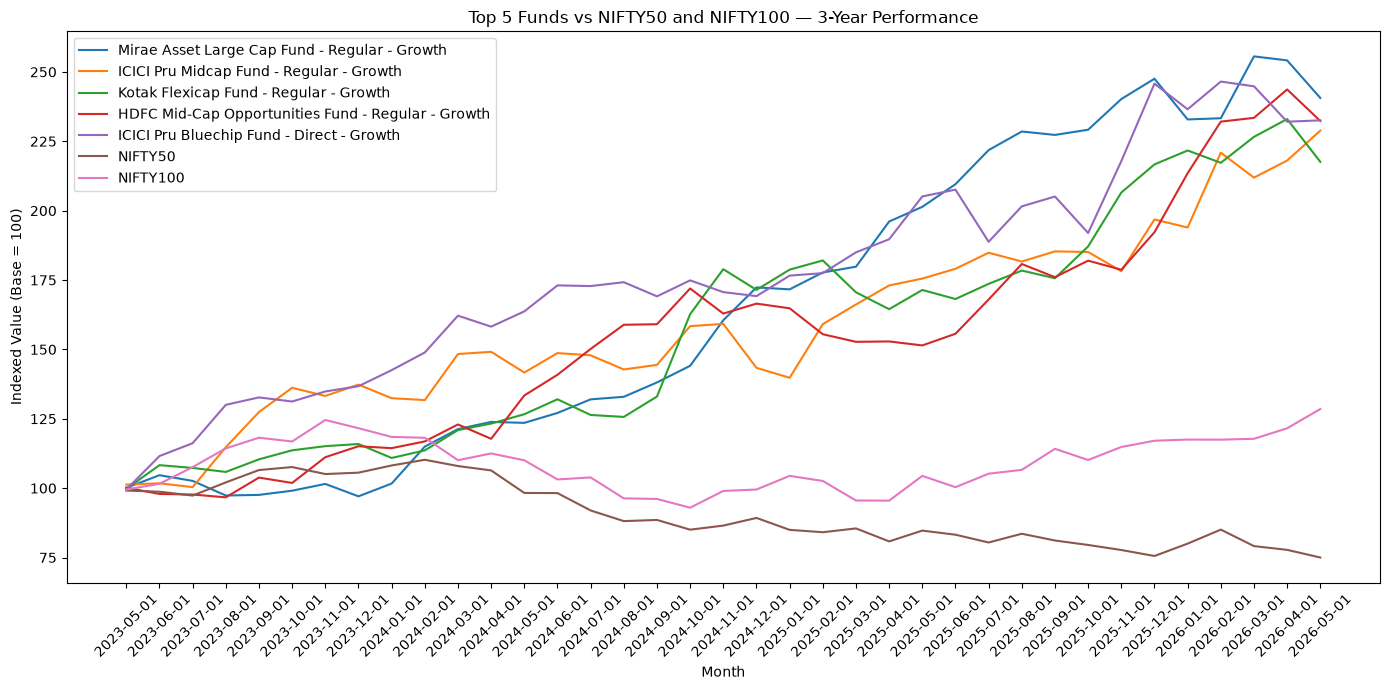

In [71]:
fig, ax = plt.subplots(figsize=(14, 7))

for code in top5["amfi_code"]:
    fund_data = monthly_comparison[monthly_comparison["amfi_code"] == code]
    name = top5.loc[top5["amfi_code"] == code, "scheme_name"].iloc[0]
    ax.plot(fund_data["month"].astype(str), fund_data["fund_index"], label=name)

benchmark_data = monthly_comparison.groupby("month").first().reset_index()

ax.plot(benchmark_data["month"].astype(str), benchmark_data["nifty50_index"], label="NIFTY50")
ax.plot(benchmark_data["month"].astype(str), benchmark_data["nifty100_index"], label="NIFTY100")

ax.set_title("Top 5 Funds vs NIFTY50 and NIFTY100 — 3-Year Performance")
ax.set_xlabel("Month")
ax.set_ylabel("Indexed Value (Base = 100)")
ax.tick_params(axis="x", rotation=45)
ax.legend()

fig.tight_layout()
fig.savefig("../reports/benchmark_comparison_top5.png", dpi=300, bbox_inches="tight")
plt.show()